In [1]:
### Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# dataset_Porter

In [3]:
### Load Data
data = pd.read_csv('dataset_Porter.csv')

In [4]:
### Display first few rows
display(data.head())

,market_id,created_at,actual_delivery_time,store_id,store_primary_category,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
0,1.0,2015-02-06 22:24:17,2015-02-06 23:27:16,df263d996281d984952c07998dc54358,american,1.0,4,3441,4,557,1239,33.0,14.0,21.0
1,2.0,2015-02-10 21:49:25,2015-02-10 22:56:29,f0ade77b43923b38237db569b016ba25,mexican,2.0,1,1900,1,1400,1400,1.0,2.0,2.0
2,3.0,2015-01-22 20:39:28,2015-01-22 21:09:09,f0ade77b43923b38237db569b016ba25,NaN,1.0,1,1900,1,1900,1900,1.0,0.0,0.0
3,3.0,2015-02-03 21:21:45,2015-02-03 22:13:00,f0ade77b43923b38237db569b016ba25,NaN,1.0,6,6900,5,600,1800,1.0,1.0,2.0
4,3.0,2015-02-15 02:40:36,2015-02-15 03:20:26,f0ade77b43923b38237db569b016ba25,NaN,1.0,3,3900,3,1100,1600,6.0,6.0,9.0


In [5]:
### Data structure and basic info
display(data.info())
display(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197428 entries, 0 to 197427
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   market_id                 196441 non-null  float64
 1   created_at                197428 non-null  object 
 2   actual_delivery_time      197421 non-null  object 
 3   store_id                  197428 non-null  object 
 4   store_primary_category    192668 non-null  object 
 5   order_protocol            196433 non-null  float64
 6   total_items               197428 non-null  int64  
 7   subtotal                  197428 non-null  int64  
 8   num_distinct_items        197428 non-null  int64  
 9   min_item_price            197428 non-null  int64  
 10  max_item_price            197428 non-null  int64  
 11  total_onshift_partners    181166 non-null  float64
 12  total_busy_partners       181166 non-null  float64
 13  total_outstanding_orders  181166 non-null  f

None

,market_id,order_protocol,total_items,subtotal,num_distinct_items,min_item_price,max_item_price,total_onshift_partners,total_busy_partners,total_outstanding_orders
count,196441.000000,196433.000000,197428.000000,197428.000000,197428.000000,197428.000000,197428.000000,181166.000000,181166.000000,181166.000000
mean,2.978706,2.882352,3.196391,2682.331402,2.670791,686.218470,1159.588630,44.808093,41.739747,58.050065
std,1.524867,1.503771,2.666546,1823.093688,1.630255,522.038648,558.411377,34.526783,32.145733,52.661830
min,1.000000,1.000000,1.000000,0.000000,1.000000,-86.000000,0.000000,-4.000000,-5.000000,-6.000000
25%,2.000000,1.000000,2.000000,1400.000000,1.000000,299.000000,800.000000,17.000000,15.000000,17.000000
50%,3.000000,3.000000,3.000000,2200.000000,2.000000,595.000000,1095.000000,37.000000,34.000000,41.000000
75%,4.000000,4.000000,4.000000,3395.000000,3.000000,949.000000,1395.000000,65.000000,62.000000,85.000000
max,6.000000,7.000000,411.000000,27100.000000,20.000000,14700.000000,14700.000000,171.000000,154.000000,285.000000


In [11]:
### Feature Engineering
# Convert timestamps to datetime format
data['created_at'] = pd.to_datetime(data['created_at'])
data['actual_delivery_time'] = pd.to_datetime(data['actual_delivery_time'])

In [13]:
### Create target column: delivery_time_in_minutes
data['delivery_time_in_minutes'] = (data['actual_delivery_time'] - data['created_at']).dt.total_seconds() / 60

In [15]:
### Extract hour of the day and day of the week
data['order_hour'] = data['created_at'].dt.hour
data['order_day'] = data['created_at'].dt.dayofweek

In [17]:
### Feature interactions
data['order_to_partner_ratio'] = data['total_outstanding_orders'] / (data['total_onshift_partners'] + 1)

In [19]:
### Handling null values
data.replace([np.inf, -np.inf], np.nan, inplace=True)  # Convert infinite values to NaN
data.dropna(inplace=True)  # Drop remaining NaN values

In [21]:
### Encoding categorical columns using One-Hot Encoding
data = pd.get_dummies(data, columns=['store_primary_category'], drop_first=True)

In [23]:
### Ensure all columns are numeric
print("Columns after encoding:", data.dtypes)


Columns after encoding: market_id                                   float64
created_at                           datetime64[ns]
actual_delivery_time                 datetime64[ns]
store_id                                     object
order_protocol                              float64
                                          ...      
store_primary_category_thai                    bool
store_primary_category_turkish                 bool
store_primary_category_vegan                   bool
store_primary_category_vegetarian              bool
store_primary_category_vietnamese              bool
Length: 89, dtype: object


In [25]:
### Drop store_id column
data.drop(columns=['store_id'], inplace=True, errors='ignore')

In [27]:
### Ensure all columns are numeric
print("Columns after encoding:", data.dtypes)


Columns after encoding: market_id                                   float64
created_at                           datetime64[ns]
actual_delivery_time                 datetime64[ns]
order_protocol                              float64
total_items                                   int64
                                          ...      
store_primary_category_thai                    bool
store_primary_category_turkish                 bool
store_primary_category_vegan                   bool
store_primary_category_vegetarian              bool
store_primary_category_vietnamese              bool
Length: 88, dtype: object


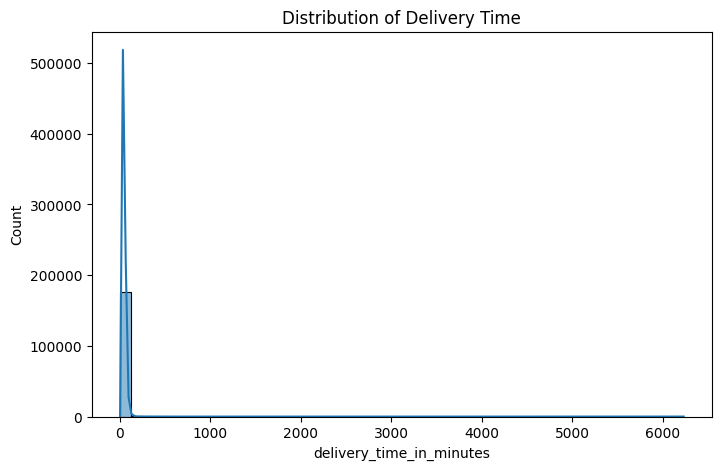

In [29]:
### Data visualization
plt.figure(figsize=(8, 5))
sns.histplot(data['delivery_time_in_minutes'], bins=50, kde=True)
plt.title('Distribution of Delivery Time')
plt.show()


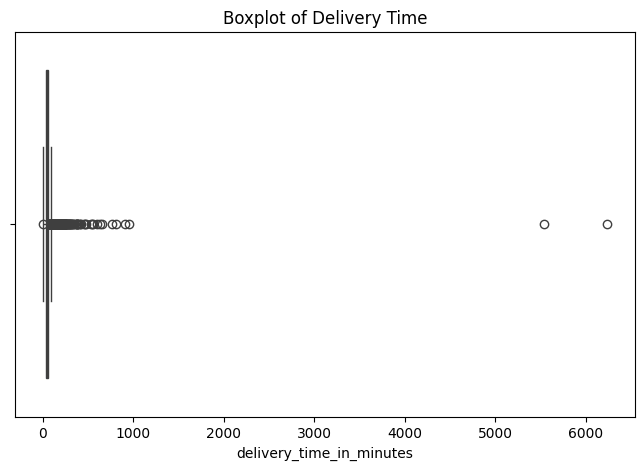

In [30]:
### Checking for outliers
plt.figure(figsize=(8, 5))
sns.boxplot(x=data['delivery_time_in_minutes'])
plt.title('Boxplot of Delivery Time')
plt.show()

In [33]:
### Outlier removal using IQR
Q1 = data['delivery_time_in_minutes'].quantile(0.25)
Q3 = data['delivery_time_in_minutes'].quantile(0.75)
IQR = Q3 - Q1


In [35]:
filtered_data = data[(data['delivery_time_in_minutes'] >= (Q1 - 1.5 * IQR)) & 
                      (data['delivery_time_in_minutes'] <= (Q3 + 1.5 * IQR))]

In [37]:
### Splitting data
X = filtered_data.drop(columns=['created_at', 'actual_delivery_time', 'delivery_time_in_minutes'])
y = filtered_data['delivery_time_in_minutes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [39]:
### Ensure all columns are numeric before scaling
print("Columns before scaling:", X_train.dtypes)

Columns before scaling: market_id                            float64
order_protocol                       float64
total_items                            int64
subtotal                               int64
num_distinct_items                     int64
                                      ...   
store_primary_category_thai             bool
store_primary_category_turkish          bool
store_primary_category_vegan            bool
store_primary_category_vegetarian       bool
store_primary_category_vietnamese       bool
Length: 85, dtype: object


In [43]:
### Check for NaN or infinite values before scaling
print("Checking for NaN values:")
print(X_train.isna().sum())
print('-----------------------------------------')
print("Checking for infinite values:")
print((X_train == np.inf).sum())


Checking for NaN values:
market_id                            0
order_protocol                       0
total_items                          0
subtotal                             0
num_distinct_items                   0
                                    ..
store_primary_category_thai          0
store_primary_category_turkish       0
store_primary_category_vegan         0
store_primary_category_vegetarian    0
store_primary_category_vietnamese    0
Length: 85, dtype: int64
-----------------------------------------
Checking for infinite values:
market_id                            0
order_protocol                       0
total_items                          0
subtotal                             0
num_distinct_items                   0
                                    ..
store_primary_category_thai          0
store_primary_category_turkish       0
store_primary_category_vegan         0
store_primary_category_vegetarian    0
store_primary_category_vietnamese    0
Length: 85, dtype: i

###

In [46]:
### Scaling the data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.astype(float))
X_test = scaler.transform(X_test.astype(float))

In [48]:
### Neural Network Model
def build_model():
    model = Sequential([
        Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        BatchNormalization(),
        Dense(1)
    ])
    optimizer = Adam(learning_rate=0.0005)
    model.compile(loss='mse', optimizer=optimizer, metrics=['mae', 'mse', 'mape'])
    return model


In [50]:
### Callbacks for improved training
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)


In [52]:
### Create model and train
model = build_model()
history = model.fit(X_train, y_train, epochs=200, validation_data=(X_test, y_test), batch_size=64, 
                    callbacks=[early_stopping, reduce_lr])

C:\Users\VEERANNA\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/200
2134/2134 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - loss: 1706.0645 - mae: 37.7561 - mape: 82.5576 - mse: 1706.0645 - val_loss: 179.7147 - val_mae: 10.3234 - val_mape: 23.6267 - val_mse: 179.7147 - learning_rate: 5.0000e-04
Epoch 2/200
2134/2134 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 177.6227 - mae: 10.4870 - mape: 25.1375 - mse: 177.6227 - val_loss: 168.4705 - val_mae: 10.2622 - val_mape: 25.1239 - val_mse: 168.4705 - learning_rate: 5.0000e-04
Epoch 3/200
2134/2134 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 173.8357 - mae: 10.4610 - mape: 25.5505 - mse: 173.8357 - val_loss: 167.9239 - val_mae: 10.2064 - val_mape: 24.8151 - val_mse: 167.9239 - learning_rate: 5.0000e-04
Epoch 4/200
2134/2134 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 171.8016 - mae: 10.3897 - mape: 25.3519 - mse: 171.8016 - val_loss: 167.3775 - val_mae: 10.2266 - val_mape: 25.0762 - val_mse: 167.3775 - learning_rate: 5.0000e-04
Epoch 5/200
2134/2134 ━━━━━━━━━━━━━━━━━━━━ 19s 4ms/step - loss: 170.3515 - mae: 10.3608

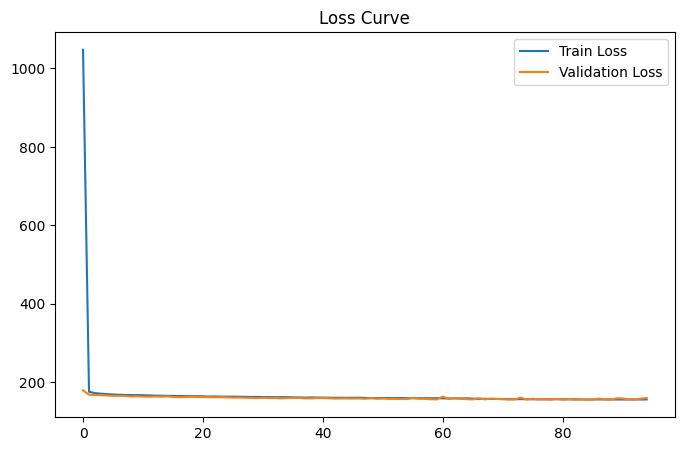

In [53]:
### Plot training history
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

In [54]:
### Predictions and evaluation
y_pred = model.predict(X_test)
print(f'MSE: {mean_squared_error(y_test, y_pred):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred):.2f}')
# print(f'MAPE: {np.mean(np.abs((y_test - y_pred) / y_test)) * 100:.2f}%')
print(f'R2 Score: {r2_score(y_test, y_pred):.2f}')


1067/1067 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
MSE: 155.63
RMSE: 12.48
MAE: 9.85
R2 Score: 0.28


In [58]:
### Export processed data to Excel
data.to_excel("processed_porter_data.xlsx", index=False)